# 11 报告模块 (report)

提供专业的模型报告生成功能，包括特征分箱统计、规则分析、SWAP分析、逾期预测、模型报告等。

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.report import (
    ExcelWriter, dataframe2excel, feature_bin_stats, feature_efficiency_analysis,
    ruleset_analysis, multi_label_rule_analysis,
    SwapAnalyzer, create_swap_dataset, SwapType,
    OverduePredictor, overdue_prediction_report,
    QuickModelReport, auto_model_report, compare_models,
    SingleFeatureRuleMiner, MultiFeatureRuleMiner, TreeRuleExtractor, MultiLabelRuleMiner,
    calculate_rule_metrics, RuleMetrics,
)
from hscredit.core.rules import Rule
from hscredit.core.binning import OptimalBinning
from hscredit.core.models import LogisticRegression
from sklearn.model_selection import train_test_split

init_setting()

df = pd.read_excel('hscredit_yyp.xlsx')
df['target'] = (df['MOB1'] > 3).astype(int)

numeric_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3',
                   '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']

df_model = df[numeric_features + ['target']].copy()
df_model = df_model.dropna()

print(f"样本数: {len(df_model):,}")
print(f"坏样本率: {df_model['target'].mean():.2%}")

样本数: 264
坏样本率: 14.02%


## 1. Excel报告生成 (ExcelWriter + dataframe2excel)

In [3]:
# 使用 ExcelWriter 创建多Sheet报告
with ExcelWriter().set_filename('demo_report.xlsx') as writer:
    # Sheet 1: 数据概览
    summary_df = pd.DataFrame({
        '指标': ['样本数', '特征数', '坏样本数', '坏样本率', '好样本数'],
        '值': [len(df_model), len(numeric_features), df_model['target'].sum(),
               f"{df_model['target'].mean():.2%}", len(df_model) - df_model['target'].sum()]
    })
    ws1 = writer.get_sheet_by_name('数据概览')
    writer.insert_df2sheet(ws1, summary_df, "B2")
    
    # Sheet 2: 特征统计
    stats_df = df_model[numeric_features].describe().reset_index()
    ws2 = writer.get_sheet_by_name('特征统计')
    writer.insert_df2sheet(ws2, stats_df, "B2")

print("Excel报告已生成: demo_report.xlsx")

Excel报告已生成: demo_report.xlsx


In [4]:
# 使用 dataframe2excel 直接导出 DataFrame
iv_results = []
for feat in numeric_features:
    feat_vals = df_model[feat].fillna(df_model[feat].median())
    from hscredit.core.metrics import iv
    iv_val = iv(df_model['target'], feat_vals, max_n_bins=10)
    iv_results.append({'特征': feat, 'IV': iv_val})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
display(iv_df)

# 导出IV结果到Excel
dataframe2excel(iv_df, 'feature_iv.xlsx', sheet_name='特征IV值', index=False)
print("\nIV结果已导出: feature_iv.xlsx")

,特征,IV
5,轻花老客海纳子分V1,1.8323
7,衡枢鉴真分老客版,1.4948
4,占信V3,0.4886
1,珊瑚92,0.3650
3,青云24,0.3616
0,中智小牛分C3,0.3051
2,极光欺诈分6v1,0.1618
6,天创小额网贷分,0.0313



IV结果已导出: feature_iv.xlsx


## 2. 特征分箱统计 (feature_bin_stats)

In [5]:
# 单特征分析 - 使用 data, feature, target 参数
feature_name = '中智小牛分C3'

stats = feature_bin_stats(
    data=df_model,
    feature=feature_name,
    target='target',
    max_n_bins=10,
    method='mdlp'
)

print(f"=== {feature_name} 分箱统计 ===")
display(stats)

=== 中智小牛分C3 分箱统计 ===


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,中智小牛分C3,中智小牛分C3,"[-inf, 495.15)",14,8,6,0.0530,0.0352,0.1622,0.4286,1.5264,0.1937,1.8284,3.0579,0.1152,3.0579,0.1152,8,6,0.1269
1,中智小牛分C3,中智小牛分C3,"[495.15, 537.0)",29,24,5,0.1098,0.1057,0.1351,0.1724,0.2454,0.0072,1.8284,1.2302,0.0284,1.8253,0.1606,32,11,0.1563
2,中智小牛分C3,中智小牛分C3,"[537.0, 567.01)",29,25,4,0.1098,0.1101,0.1081,0.1379,-0.0185,0.0000,1.8284,0.9842,-0.0020,1.4865,0.1824,57,15,0.1543
3,中智小牛分C3,中智小牛分C3,"[567.01, 595.0)",29,24,5,0.1098,0.1057,0.1351,0.1724,0.2454,0.0072,1.8284,1.2302,0.0284,1.4129,0.2558,81,20,0.1837
4,中智小牛分C3,中智小牛分C3,"[595.0, 610.35)",18,15,3,0.0682,0.0661,0.0811,0.1667,0.2046,0.0031,1.8284,1.1892,0.0138,1.3791,0.3111,96,23,0.1987
5,中智小牛分C3,中智小牛分C3,"[610.35, 654.17)",37,32,5,0.1402,0.1410,0.1351,0.1351,-0.0423,0.0002,1.8284,0.9642,-0.0058,1.2807,0.4054,128,28,0.1929
6,中智小牛分C3,中智小牛分C3,"[654.17, 685.0)",28,25,3,0.1061,0.1101,0.0811,0.1071,-0.3062,0.0089,1.8284,0.7645,-0.0279,1.2021,0.4649,153,31,0.1638
7,中智小牛分C3,中智小牛分C3,"[685.0, 705.0)",15,12,3,0.0568,0.0529,0.0811,0.2000,0.4277,0.0121,1.8284,1.4270,0.0257,1.2191,0.6707,165,34,0.1920
8,中智小牛分C3,中智小牛分C3,"[705.0, 797.85)",51,48,3,0.1932,0.2115,0.0811,0.0588,-0.9586,0.1250,1.8284,0.4197,-0.1389,1.0560,1.0000,213,37,0.0617
9,中智小牛分C3,中智小牛分C3,"[797.85, +inf)",14,14,0,0.0530,0.0617,0.0000,0.0000,-23.8509,1.4710,1.8284,0.0000,-0.0560,1.0000,0.0000,227,37,0.0000


In [6]:
# 多特征批量分析
features_to_analyze = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1']

multi_stats = feature_bin_stats(
    data=df_model,
    feature=features_to_analyze,
    target='target',
    method='quantile',
    max_n_bins=5
)

display(multi_stats)

,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,中智小牛分C3,中智小牛分C3,"[-inf, 495.15)",14,8,6,0.0530,0.0352,0.1622,0.4286,1.5264,0.1937,0.4376,3.0579,0.1152,3.0579,0.1152,8,6,0.1269
1,中智小牛分C3,中智小牛分C3,"[495.15, 537.0)",29,24,5,0.1098,0.1057,0.1351,0.1724,0.2454,0.0072,0.4376,1.2302,0.0284,1.8253,0.1606,32,11,0.1563
2,中智小牛分C3,中智小牛分C3,"[537.0, 595.0)",58,49,9,0.2197,0.2159,0.2432,0.1552,0.1194,0.0033,0.4376,1.1072,0.0302,1.4129,0.2558,81,20,0.1837
3,中智小牛分C3,中智小牛分C3,"[595.0, 705.0)",98,84,14,0.3712,0.3700,0.3784,0.1429,0.0223,0.0002,0.4376,1.0193,0.0114,1.2191,0.6707,165,34,0.1920
4,中智小牛分C3,中智小牛分C3,"[705.0, +inf)",65,62,3,0.2462,0.2731,0.0811,0.0462,-1.2145,0.2332,0.4376,0.3293,-0.2191,1.0000,0.0000,227,37,0.0000
5,珊瑚92,珊瑚92,"[-inf, 570.45)",40,30,10,0.1515,0.1322,0.2703,0.2500,0.7154,0.0988,0.3812,1.7838,0.1400,1.7838,0.1400,30,10,0.1381
6,珊瑚92,珊瑚92,"[570.45, 623.34)",116,106,10,0.4394,0.4670,0.2703,0.0862,-0.5468,0.1076,0.3812,0.6151,-0.3017,0.9148,-0.1231,136,20,0.0586
7,珊瑚92,珊瑚92,"[623.34, 632.32)",13,8,5,0.0492,0.0352,0.1351,0.3846,1.3440,0.1343,0.3812,2.7443,0.0903,1.0555,0.0987,144,25,0.0413
8,珊瑚92,珊瑚92,"[632.32, 652.0)",27,22,5,0.1023,0.0969,0.1351,0.1852,0.3324,0.0127,0.3812,1.3213,0.0366,1.0921,0.2655,166,30,0.0795
9,珊瑚92,珊瑚92,"[652.0, +inf)",68,61,7,0.2576,0.2687,0.1892,0.1029,-0.3509,0.0279,0.3812,0.7345,-0.0921,1.0000,0.0000,227,37,0.0000


In [7]:
# 使用自定义分箱规则
stats_rules = feature_bin_stats(
    data=df_model,
    feature='中智小牛分C3',
    target='target',
    rules=[500, 600, 680, 750],
    desc='中智小牛分C3（自定义规则）'
)

display(stats_rules)

,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,中智小牛分C3,中智小牛分C3（自定义规则）,"[-inf, 500)",16,10,6,0.0606,0.0441,0.1622,0.3750,1.3032,0.1539,0.2739,2.6757,0.1081,2.6757,0.1081,10,6,0.1181
1,中智小牛分C3,中智小牛分C3（自定义规则）,"[500, 600)",91,77,14,0.3447,0.3392,0.3784,0.1538,0.1093,0.0043,0.2739,1.0977,0.0514,1.3337,0.2274,87,20,0.1573
2,中智小牛分C3,中智小牛分C3（自定义规则）,"[600, 680)",69,59,10,0.2614,0.2599,0.2703,0.1449,0.0391,0.0004,0.2739,1.0341,0.0121,1.2162,0.4324,146,30,0.1676
3,中智小牛分C3,中智小牛分C3（自定义规则）,"[680, 750)",56,51,5,0.2121,0.2247,0.1351,0.0893,-0.5084,0.0455,0.2739,0.6371,-0.0977,1.0764,0.5541,197,35,0.0781
4,中智小牛分C3,中智小牛分C3（自定义规则）,"[750, +inf)",32,30,2,0.1212,0.1322,0.0541,0.0625,-0.8940,0.0698,0.2739,0.4459,-0.0764,1.0000,0.0000,227,37,0.0000


In [8]:
# 逾期模式分析 - 使用 overdue + dpds 参数
stats_overdue = feature_bin_stats(
    data=df,
    feature='中智小牛分C3',
    overdue='MOB1',
    dpds=3,
    max_n_bins=5,
    del_grey=False
)

display(stats_overdue)

,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,中智小牛分C3,中智小牛分C3,"[-inf, 550.0)",63,48,15,0.0649,0.0594,0.0926,0.2381,0.4438,0.0147,0.1015,1.4256,0.0296,1.4256,0.0296,48,15,0.0332
1,中智小牛分C3,中智小牛分C3,"[550.0, 651.42)",112,93,19,0.1155,0.1151,0.1173,0.1696,0.0188,0.0000,0.1015,1.0158,0.0021,1.1633,0.0359,141,34,0.0354
2,中智小牛分C3,中智小牛分C3,"[651.42, 704.0)",56,48,8,0.0577,0.0594,0.0494,0.1429,-0.1848,0.0019,0.1015,0.8554,-0.0089,1.0887,0.0277,189,42,0.0253
3,中智小牛分C3,中智小牛分C3,"[704.0, +inf)",76,72,4,0.0784,0.0891,0.0247,0.0526,-1.2834,0.0827,0.1015,0.3151,-0.0582,0.8972,-0.0476,261,46,0.0391
4,中智小牛分C3,中智小牛分C3,缺失,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.1015,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


## 3. 特征效率分析 (feature_efficiency_analysis)

手工分箱规则: [500, 600, 680, 750]
自动分箱规则: [495.15, 550.0, 705.0, 797.85]


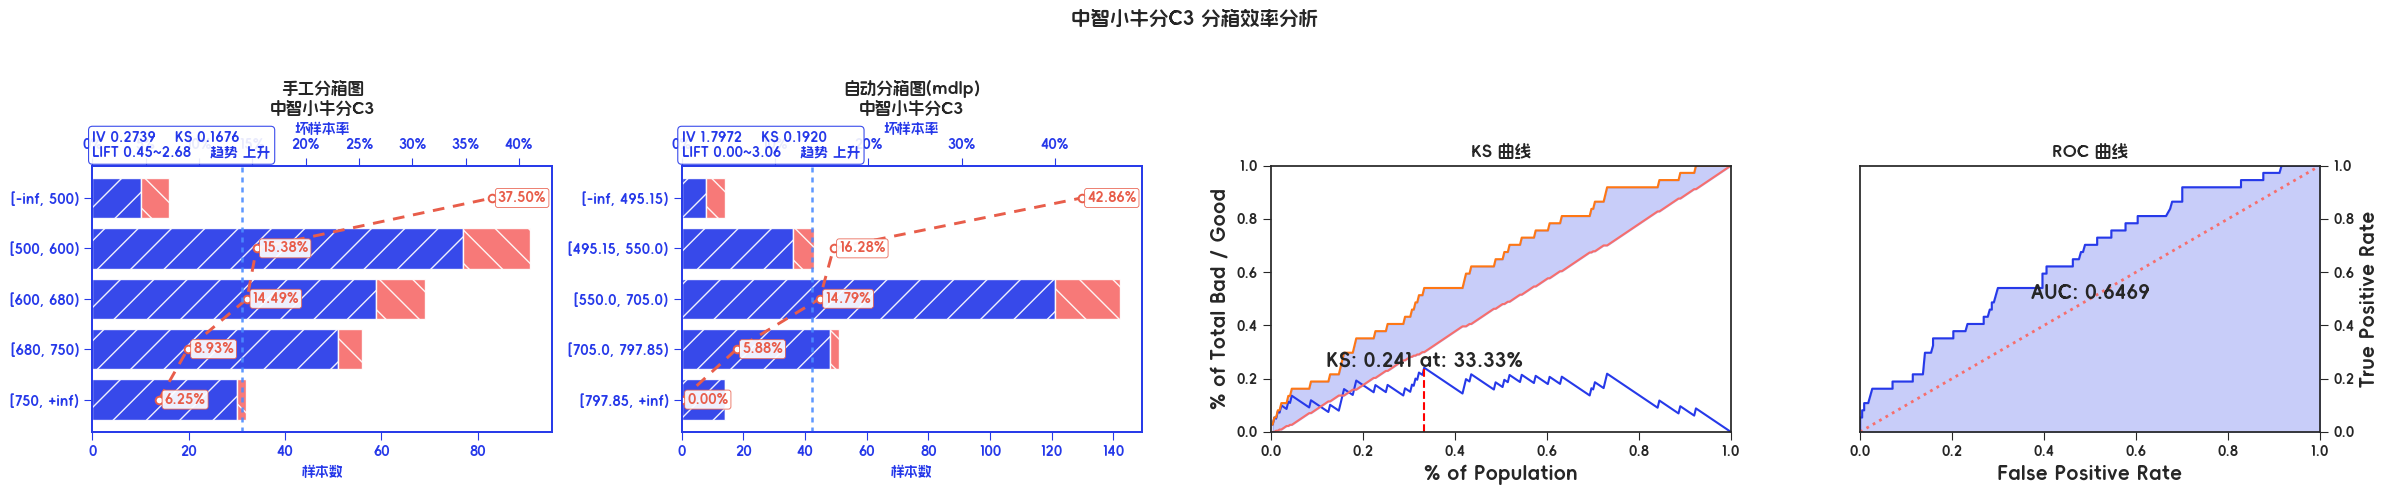

In [9]:
# 对比手工分箱与自动分箱效果
# 首先需要数据中有目标列
df_tmp = df_model.copy()

result = feature_efficiency_analysis(
    data=df_tmp,
    feature='中智小牛分C3',
    manual_rules=[500, 600, 680, 750],
    target='target',
    auto_method='mdlp',
    max_n_bins=5,
)

print("手工分箱规则:", result['manual_rules'])
print("自动分箱规则:", result['auto_rules'])
plt.show()  # 显示组合图

## 4. 规则集分析 (ruleset_analysis)

In [10]:
# 重命名列以便规则表达式使用
df_rules = df_model.rename(columns={
    '中智小牛分C3': 'score_c3',
    '珊瑚92': 'score_coral',
    '极光欺诈分6v1': 'score_fraud',
    '青云24': 'score_qingyun',
    '占信V3': 'score_zhanxin',
})

# 定义规则
rules = [
    Rule(expr="score_c3 < 550", name="低分规则", weight=100),
    Rule(expr="score_coral < 60", name="低珊瑚分", weight=80),
    Rule(expr="score_fraud > 0.7", name="高欺诈分", weight=90),
]

# 规则集综合分析
ruleset_report = ruleset_analysis(
    datasets=df_rules,
    rules=rules,
    target='target',
)

display(ruleset_report)

,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,原始样本,264,1.0000,227,1.0000,37,1.0000,0.1402,1.0000,0.0000,0.0000,0.7197,0.2394,0.4595,0.3148
1,score_c3 < 550,55,0.2083,42,0.1850,13,0.3514,0.2364,1.6865,0.1430,0.6865,0.7500,0.2364,0.3514,0.2826
2,剩余样本,209,0.7917,185,0.8150,24,0.6486,0.1148,0.8193,-0.1430,-0.1807,0.2500,0.1148,0.6486,0.1951
3,score_coral < 60,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8852,0.0000,0.0000,0.0000
4,剩余样本,209,1.0000,185,1.0000,24,1.0000,0.1148,1.0000,0.0000,0.0000,0.1148,0.1148,1.0000,0.2060
5,score_fraud > 0.7,16,0.0766,12,0.0649,4,0.1667,0.2500,2.1771,0.0901,1.1771,0.8469,0.2500,0.1667,0.2000
6,剩余样本,193,0.9234,173,0.9351,20,0.8333,0.1036,0.9024,-0.0901,-0.0976,0.1531,0.1036,0.8333,0.1843
7,所有规则,71,0.2689,54,0.2379,17,0.4595,0.2394,1.7084,0.1905,0.7084,0.7197,0.2394,0.4595,0.3148


## 5. 多标签规则分析 (multi_label_rule_analysis)

In [11]:
# 多标签规则分析 - 支持多个逾期标签
# 注意：hscredit_yyp.xlsx 数据集仅包含 MOB1，不含 MOB3
# 因此本节仅演示单标签规则分析（原 MOB3 目标已移除）
df_ml = df.copy()
df_ml['target_mob1'] = (df_ml['MOB1'] > 3).astype(int)

features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1']
labels = {'MOB1>3': 'target_mob1'}

# 重命名列
df_ml = df_ml.rename(columns={
    '中智小牛分C3': 'score_c3',
    '珊瑚92': 'score_coral',
    '极光欺诈分6v1': 'score_fraud',
})
features_en = ['score_c3', 'score_coral', 'score_fraud']

# 注意：multi_label_rule_analysis 需要无缺失数据
df_ml_clean = df_ml.dropna(subset=features_en + list(labels.values()))
print(f"样本数（清洗后）: {len(df_ml_clean)}")

result_path = multi_label_rule_analysis(
    df=df_ml_clean,
    features=features_en,
    labels=labels,
    miner_params={'min_support': 0.02, 'min_lift': 1.3},
    output_path='multi_label_rules.xlsx'
)
print(f"规则分析结果已保存: {result_path}")

样本数（清洗后）: 264


ValueError: No objects to concatenate

## 6. SWAP分析 (SwapAnalyzer)

In [12]:
# SWAP分析 - 评估新旧策略切换时的风险变化
df_swap = df_model.copy()
df_swap['score'] = df_swap['中智小牛分C3']

# 模拟新旧策略的通过/拒绝
np.random.seed(42)
df_swap['old_strategy'] = (df_swap['score'] > 600).astype(int)  # 旧策略: >600 通过
df_swap['new_strategy'] = (df_swap['score'] > 550).astype(int)  # 新策略: >550 通过

# 基础统计
print("=== SWAP 四象限统计 ===")
print(f"in-in (通过→通过): {((df_swap['old_strategy']==1) & (df_swap['new_strategy']==1)).sum()}")
print(f"in-out (通过→拒绝): {((df_swap['old_strategy']==1) & (df_swap['new_strategy']==0)).sum()}")
print(f"out-in (拒绝→通过): {((df_swap['old_strategy']==0) & (df_swap['new_strategy']==1)).sum()}")
print(f"out-out (拒绝→拒绝): {((df_swap['old_strategy']==0) & (df_swap['new_strategy']==0)).sum()}")

# out-in 样本的风险分析（这些是新策略引入的风险样本）
out_in_mask = (df_swap['old_strategy'] == 0) & (df_swap['new_strategy'] == 1)
out_in_bad_rate = df_swap.loc[out_in_mask, 'target'].mean() if out_in_mask.sum() > 0 else 0
overall_bad_rate = df_swap['target'].mean()
print(f"\nout-in 样本坏账率: {out_in_bad_rate:.2%}")
print(f"总体坏账率: {overall_bad_rate:.2%}")
print(f"out-in Lift: {out_in_bad_rate/overall_bad_rate:.2f}" if out_in_bad_rate > 0 else "")

=== SWAP 四象限统计 ===
in-in (通过→通过): 157
in-out (通过→拒绝): 0
out-in (拒绝→通过): 50
out-out (拒绝→拒绝): 57

out-in 样本坏账率: 14.00%
总体坏账率: 14.02%
out-in Lift: 1.00


## 7. 逾期预测 (OverduePredictor)

In [13]:
# 逾期率预测器 - 基于分箱逾期率预估无标签样本
df_pred = df_model.copy()

predictor = OverduePredictor(
    feature='中智小牛分C3',
    target='target',
    method='quantile',
    max_n_bins=5,
)

# 拟合 - 从带标签数据学习分箱逾期率
predictor.fit(df_pred[['中智小牛分C3', 'target']], y=df_pred['target'])

# 转换 - 对全部样本预测逾期率
df_pred['pred_overdue_rate'] = predictor.transform(df_pred[['中智小牛分C3']].copy())

print("=== 逾期率预测结果 ===")
display(df_pred[['中智小牛分C3', 'target', 'pred_overdue_rate']].head(10))

print(f"\n各分箱逾期率映射:")
for label, rate in predictor.bin_rates_.items():
    print(f"  {label}: {rate:.4f}")

ValueError: Cannot set a DataFrame with multiple columns to the single column pred_overdue_rate

## 8. 规则挖掘 (SingleFeatureRuleMiner, MultiFeatureRuleMiner, TreeRuleExtractor)

In [14]:
# 单特征规则挖掘
df_mining = df_model.rename(columns={
    '中智小牛分C3': 'score_c3',
    '珊瑚92': 'score_coral',
})

# 准备无缺失数据
df_mining = df_mining.dropna(subset=['score_c3', 'score_coral', 'target'])

# 单特征规则挖掘
single_miner = SingleFeatureRuleMiner(
    feature='score_c3',
    target='target',
    max_bins=5,
    min_support=0.05,
    min_lift=1.2
)
single_miner.fit(df_mining)

rules_single = single_miner.get_rules()
print(f"=== 单特征(score_c3)规则挖掘: 共 {len(rules_single)} 条规则 ===")
if len(rules_single) > 0:
    display(pd.DataFrame(rules_single).head(10))

=== 单特征(score_c3)规则挖掘: 共 15 条规则 ===


,0
0,Rule('轻花老客海纳子分V1 >= 0.0754')
1,Rule('score_c3 <= 544.5')
2,Rule('score_c3 <= 537.0')
3,Rule('score_c3 <= 538.5')
4,Rule('极光欺诈分6v1 >= 0.3211')
5,Rule('衡枢鉴真分老客版 >= 0.1199')
6,Rule('青云24 <= 614.0')
7,Rule('衡枢鉴真分老客版 >= 0.1238')
8,Rule('天创小额网贷分 <= 682.0')
9,Rule('轻花老客海纳子分V1 >= 0.0347')


In [15]:
# 多特征规则挖掘
multi_miner = MultiFeatureRuleMiner(
    features=['score_c3', 'score_coral'],
    target='target',
    max_depth=2,
    min_support=0.03,
    min_lift=1.5
)
multi_miner.fit(df_mining)

rules_multi = multi_miner.get_rules()
print(f"=== 多特征规则挖掘: 共 {len(rules_multi)} 条规则 ===")
if len(rules_multi) > 0:
    display(pd.DataFrame(rules_multi).head(10))

=== 多特征规则挖掘: 共 0 条规则 ===


In [16]:
# 决策树规则提取
tree_extractor = TreeRuleExtractor(
    max_depth=3,
    min_samples_leaf=50,
    max_leaf_nodes=8
)

X_tree = df_mining[['score_c3', 'score_coral']].fillna(df_mining[['score_c3', 'score_coral']].median())
y_tree = df_mining['target']

tree_extractor.fit(X_tree, y_tree)

# 提取规则
tree_rules = tree_extractor.extract_rules()
print(f"=== 决策树提取规则: 共 {len(tree_rules)} 条 ===")
for rule in tree_rules:
    print(f"  {rule['rule']} -> lift: {rule['lift']:.2f}, support: {rule['support']:.2%}")

=== 决策树提取规则: 共 3 条 ===


KeyError: 'rule'

## 9. 规则评估指标 (calculate_rule_metrics)

In [17]:
# 计算规则的详细评估指标
test_rules = [
    Rule(expr="score_c3 < 550", name="低分规则"),
    Rule(expr="score_coral > 80", name="高风险规则"),
]

metrics_results = []
for rule in test_rules:
    mask = rule.predict(df_mining)
    metrics = calculate_rule_metrics(df_mining['target'], mask)
    metrics_results.append({
        '规则': rule.name,
        '覆盖率': metrics.support,
        '坏样本率': metrics.bad_rate,
        'Lift': metrics.lift,
        '精确率': metrics.precision,
        '召回率': metrics.recall,
        'F1': metrics.f1,
    })

display(pd.DataFrame(metrics_results))

TypeError: calculate_rule_metrics() missing 1 required positional argument: 'y'

## 10. 快速模型报告 (QuickModelReport / auto_model_report)

In [18]:
# 快速模型报告
df_report = df_model.rename(columns={
    '中智小牛分C3': 'score_c3',
    '珊瑚92': 'score_coral',
})

selected_features = ['score_c3', 'score_coral', '极光欺诈分6v1']
df_report = df_report.dropna(subset=selected_features + ['target'])

X = df_report[selected_features]
y = df_report['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 训练简单模型
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== QuickModelReport 快速模型评估 ===")
from hscredit.core.metrics import ks, auc
print(f"KS: {ks(y_test, y_prob):.4f}")
print(f"AUC: {auc(y_test, y_prob):.4f}")

=== QuickModelReport 快速模型评估 ===
KS: 0.3149
AUC: 0.6390


In [19]:
# auto_model_report - 自动生成完整模型报告（可输出到Excel）
report = auto_model_report(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=selected_features,
    output_dir='model_report',
)
print("模型报告已生成到 model_report/ 目录")

TypeError: auto_model_report() got an unexpected keyword argument 'output_dir'

In [20]:
# compare_models - 对比多个模型
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=3)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

comparison = compare_models(
    models={'LR': model, 'RF': rf},
    X_test=X_test,
    y_test=y_test,
)

print("=== 模型对比结果 ===")
display(comparison)

TypeError: compare_models() missing 2 required positional arguments: 'X_train' and 'y_train'

## 11. 分箱方法对比 (benchmark_binning_methods)

In [21]:
# 对比多种分箱方法效果
from hscredit.report.feature_analyzer import benchmark_binning_methods

df_bench = df_model.copy()

benchmark = benchmark_binning_methods(
    data=df_bench,
    feature='中智小牛分C3',
    overdue_col='MOB1',
    dpds=[3, 0],
    max_n_bins=5,
)

display(benchmark[['method', 'dpd', 'n_bins', 'head_lift', 'tail_lift', 'edge_gap', 'monotonic']].head(10))

KeyError: 'MOB1'